In [40]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/anirbanmaitra/puppy-image'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anirbanmaitra/puppy-image/cat.jpg
/kaggle/input/datasets/anirbanmaitra/puppy-image/dog.avif


In [41]:
from keras.preprocessing import image
from keras.src.legacy.preprocessing.image import ImageDataGenerator


In [42]:
img = image.load_img('/kaggle/input/datasets/anirbanmaitra/puppy-image/dog.avif', target_size = (200, 200))

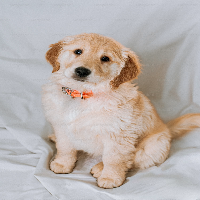

In [43]:
img

In [44]:
type(img)

PIL.Image.Image

In [45]:
datagen = ImageDataGenerator(
    rotation_range = 30,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    #fill_mode = 'reflect' # or 'constant' to fill when there is a shift
)

In [46]:
img = image.img_to_array(img) #Convert from PIL.Image.Image to numpy array

In [47]:
type(img)

numpy.ndarray

In [48]:
img.shape

(200, 200, 3)

In [49]:
input_batch = img.reshape(1, 200, 200, 3)

In [50]:
import os
dir_name = '/kaggle/working/augmented'
os.makedirs(dir_name, exist_ok = True)
print(f"Directory {dir_name} created Successfully!")

Directory /kaggle/working/augmented created Successfully!


In [51]:
i = 0
for output in datagen.flow(input_batch, batch_size=1, save_to_dir = '/kaggle/working/augmented'): # .flow for 1 image and .flow_from_directory for full directory
    i = i + 1
    if i == 10:
        break

In [52]:
# Syntax: !zip -r <archive_name>.zip /kaggle/working/<your_folder_name>
!zip -r augmented.zip /kaggle/working/augmented

  adding: kaggle/working/augmented/ (stored 0%)
  adding: kaggle/working/augmented/_0_6562.png (deflated 0%)
  adding: kaggle/working/augmented/_0_2743.png (deflated 0%)
  adding: kaggle/working/augmented/_0_7936.png (deflated 0%)
  adding: kaggle/working/augmented/_0_3242.png (deflated 0%)
  adding: kaggle/working/augmented/_0_786.png (deflated 0%)
  adding: kaggle/working/augmented/_0_9513.png (deflated 0%)
  adding: kaggle/working/augmented/_0_3001.png (deflated 0%)
  adding: kaggle/working/augmented/_0_8386.png (deflated 0%)
  adding: kaggle/working/augmented/_0_4717.png (deflated 0%)
  adding: kaggle/working/augmented/_0_608.png (deflated 0%)


In [53]:
from IPython.display import FileLink

# Generates a clickable link to download your file directly
FileLink(r'augmented.zip')

/kaggle/working/augmented.zip

In [39]:
# Delete a directory and all of its contents recursively
# !rm -rf /kaggle/working/augmented.zip

## Augmentation over a batch of Images

```python
batch_size = 16

# this is augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
    rotation_range = 30,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    #fill_mode = 'reflect' # or 'constant' to fill when there is a shift
)

# We will only apply rescaling operation as augmentation over test data
test_datagen = ImageDataGenerator(rescale = 1./255)

# this is a generator that will read pictures found in
# subfolders of 'data/train', and indefinitely generate
# batches of augmented image data
train_generator = train_datagen.flow_from_directory(
    'data/train', # this is the target directory
    target_size = (150, 150),
    batch_size = batch_size,
    class_mode = 'binary' # since we use binary_crossentropy thus we need binary labels
)

# this is a similar generator for validation data
validation_generator = test_datagen.flow_from_directory(
    'data/valid',
    target_size = (150, 150),
    batch_size = batch_size,
    class_mode = 'binary'
)



######  During training  #######
model.fit_generator(
    train_generator, # original images are not used only augmented images are used
    steps_per_epoch = 2000 // batch_size,
    epochs = 25,
    validation_data = validation_generator,
    validation_steps = 800 // batch_size
)
```